In [ ]:
import pandas as pd
import tensorflow as tf
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
!pip show tensorflow

Name: tensorflow
Version: 2.20.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.13/dist-packages
Requires: absl-py, astunparse, flatbuffers, gast, google_pasta, grpcio, h5py, keras, libclang, ml_dtypes, numpy, opt_einsum, packaging, protobuf, requests, setuptools, six, tensorboard, termcolor, typing_extensions, wrapt
Required-by: dopamine_rl, tensorflow-text, tf_keras, ydf_tf


In [ ]:
def build_model(rate):
    # Строим модель в виде последовательно подключаемых
    # слоев (промежуточные слои соединяются автоматом).
    model = tf.keras.models.Sequential()
    # В нашем случае в виде одного слоя из
    # одного единственного нейрона:
    model.add(tf.keras.layers.Dense(units=1, # количество нейроно
                                    input_shape=(1,))) # размерность входов
    # Скомпилируем нашу модель в код, который исполнит
    # TensorFlow. В качестве функции потерь, которую
    # мы будем минимизировать, выберем среднеквадратическую ошибку
    model.compile(optimizer=tf.keras.optimizers.RMSprop(
            learning_rate=rate), loss="mean_squared_error",
                  metrics=[tf.keras.metrics.RootMeanSquaredError()])

    return model


In [ ]:
def train_model(model, feature, label, epochs, batch_size):
    history = model.fit(x=feature, # входные данные ("признаки")
        y=label, # выходные дынные ("метки")
            batch_size=batch_size, # размер пакета данных для одной эпохи градиетного спуска
                        epochs=epochs) # общее число эпох обучения

    # Сохраняем итоговые веса нейрона в отдельные переменные
    trained_weight = model.get_weights()[0][0][0]
    trained_bias = model.get_weights()[1]
    # Отдельно сохраним список эпох обучения
    epochs = history.epoch
    # Преобразуем данные к формату Pandas.DataFrame
    hist = pd.DataFrame(history.history)
    # Сохраним данные о среднеквадратической ошибке
    rmse = hist["root_mean_squared_error"]

    return trained_weight, trained_bias, epochs, rmse


In [ ]:
def plot_the_model(trained_weight, trained_bias, feature, label):
    plt.xlabel("feature")
    plt.ylabel("label")
    # входные данные по оси x, выходные по оси y
    plt.scatter(feature, label)
    # Модель линейной регрессии будет представлена красной линией
    # с началом в (x0, y0) и концом в (x1, y1).
    x0 = 0
    y0 = trained_bias
    x1 = feature[-1]
    y1 = trained_bias + (trained_weight * x1)
    plt.plot([x0, x1], [y0, y1], c="r")
    plt.show()

In [ ]:
def plot_the_loss_curve(epochs, rmse):
    plt.figure()
    plt.xlabel("Epoch")
    plt.ylabel("Root Mean Squared Error")
    plt.plot(epochs, rmse, label="Loss")
    plt.legend()
    plt.ylim([rmse.min()*0.97, rmse.max()])
    plt.show()


In [ ]:
features=np.array([1.0,2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0,10.0,11.0,12.0])
labels=np.array([5.0,8.8, 9.6,14.2,18.8,19.5,21.4,26.8,28.9,32.0,33.8,38.2])

Epoch 1/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 561ms/step - loss: 288.7684 - root_mean_squared_error: 16.9932
Epoch 2/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 279.9767 - root_mean_squared_error: 16.7325
Epoch 3/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 273.7299 - root_mean_squared_error: 16.5448
Epoch 4/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 268.5769 - root_mean_squared_error: 16.3883
Epoch 5/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 264.0590 - root_mean_squared_error: 16.2499
Epoch 6/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 259.9640 - root_mean_squared_error: 16.1234
Epoch 7/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - loss: 256.1739 - root_mean_squared_error: 16.0054
Epoch 8/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 252.6154 - root_mean_squared_error: 15.8939
Epoch 9/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 249.2395 - root_mean_squared_error: 15.7873
Epoch 10/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 246.0117 - root_mean

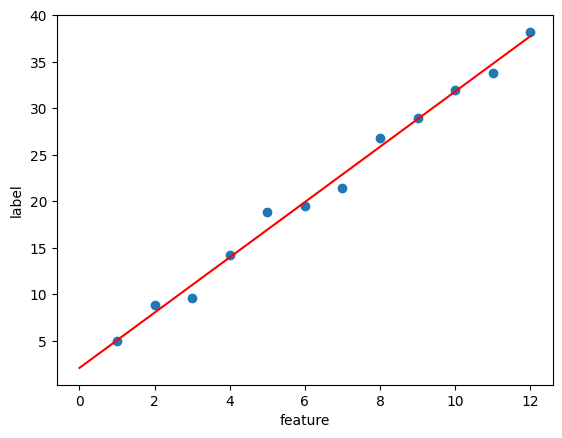

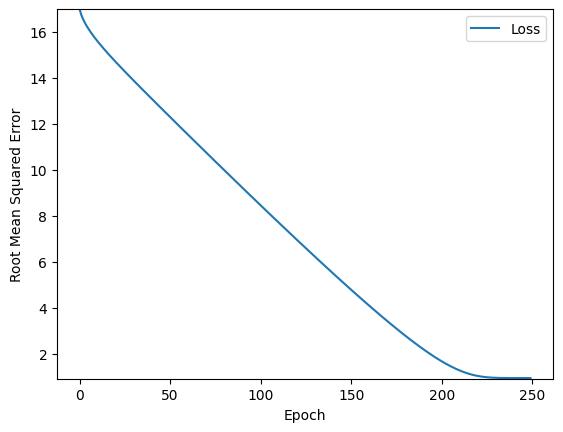

In [ ]:
learning_rate=0.01 # выберем малую скорость обучения
epochs=250 # возьмем небольшое число эпох для обучения
my_batch_size=12 # задействуем все обучающие примеры за одну эпоху обучения.

my_model = build_model(learning_rate)
trained_weight, trained_bias, epochs, rmse = train_model(my_model, features,
labels, epochs,
my_batch_size)
plot_the_model(trained_weight, trained_bias, features, labels)
plot_the_loss_curve(epochs, rmse)


In [ ]:
pitiygolnik = np.array([
    [-1,1],
    [-1,-1],
    [1,0],
    [-1,0],
    [0,1]
])
def between(var, v_min, v_max):
    return (var >= v_min) & (var <= v_max)


In [ ]:
def make_dots(n = 10_000):
  XY = np.random.uniform(-1.5,1.5, size = (n,2)).astype(np.float32)
  x = XY[:,0]
  y = XY[:,1]

  inside = between(x, -1, 1) & (y >= -1) & (y <= x + 1) & (y <= -x + 1)

  cond_4 =   ~inside

  cond_1 = (between(x, -1, 0) & between(y, 0, 1) & (y <= x + 1)) | \
          (between(x, 0, 1) & between(y, -1, 0) & (y >= -x))

  cond_2 = between(x, -1, 1) & between(y, -1, 0) & (y <= x) & (y <= -x)

  cond_3 = (between(x, -1, 0) & between(y, -1, 0) & (y >= x)) | \
            (between(x, 0, 1) & between(y, 0, 1) & (y <= -x + 1))


  labels = np.zeros(n, dtype=int)
  labels[cond_4] = 4
  labels[cond_1] = 1
  labels[cond_2] = 2
  labels[cond_3] = 3



  return XY, labels

In [ ]:
XY, labels = make_dots()

df = pd.DataFrame({
    "X": XY[:,0],
    "Y": XY[:,1],
    "label": labels.astype(int)
})
df.head()


,X,Y,label
0,-0.990221,-0.009420,3
1,0.651241,1.260717,4
2,0.485528,-0.976407,2
3,0.444907,-0.733483,2
4,-0.464951,-0.808022,2


<Axes: xlabel='X', ylabel='Y'>

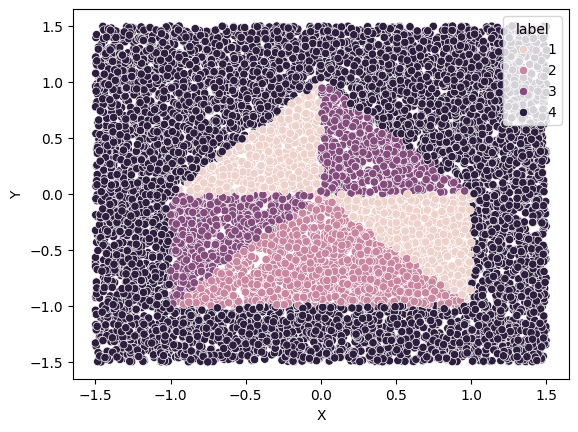

In [ ]:
sns.scatterplot(data = df,x = "X",y = "Y",hue="label")

In [ ]:
Y = tf.keras.utils.to_categorical(labels - 1,num_classes = 4)
split = int(len(XY) * 0.8)
X_train,X_test =  XY[:split], XY[split:]
y_train, y_test =  Y[:split], Y[split:]

In [ ]:
def build_model(rate, neurons = 9):
    model = tf.keras.Sequential([
        tf.keras.Input( shape=(2,) ),
        tf.keras.layers.Dense(neurons,activation="relu"),
        tf.keras.layers.Dense(4,activation="softmax")
    ])
    model.compile(
        optimizer = tf.keras.optimizers.RMSprop(
            learning_rate = rate
        ),
        loss = "categorical_crossentropy",
        metrics = ["accuracy"]
    )
    return model

In [ ]:
model = build_model(rate = 0.01, neurons=9)

In [ ]:
model.fit(x = X_train, y = y_train, epochs=200, batch_size=24, validation_split=0.1)

Epoch 1/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7458 - loss: 0.6058 - val_accuracy: 0.8612 - val_loss: 0.3930
Epoch 2/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9014 - loss: 0.3301 - val_accuracy: 0.9112 - val_loss: 0.2636
Epoch 3/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9254 - loss: 0.2504 - val_accuracy: 0.9362 - val_loss: 0.2083
Epoch 4/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9349 - loss: 0.2116 - val_accuracy: 0.9488 - val_loss: 0.1778
Epoch 5/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9372 - loss: 0.1909 - val_accuracy: 0.9475 - val_loss: 0.1653
Epoch 6/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9406 - loss: 0.1764 - val_accuracy: 0.9513 - val_loss: 0.1567
Epoch 7/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9428 - loss: 0.1653 - val_accuracy: 0.9538 - val_loss: 0.1496
Epoch 8/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9476 - loss: 0.1560 - val_accu

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test, y_test, verbose = 0
)
print(f"test loss : {test_loss}")
print(f"test acc : {test_accuracy}" )

test loss : 0.025867318734526634
test acc : 0.9904999732971191


In [ ]:
def plot_curve(model):

  hist = model.history.history
  fig, (ax1, ax2) = plt.subplots(1,2, figsize= (12,4))

  ax1.plot(hist["loss"], label = "обучение")
  ax1.plot(hist["val_loss"], label = "валидация")
  ax1.set_title("ошибка")
  ax1.set_ylabel("энтропия")
  ax1.set_xlabel("эпоха")
  ax1.legend()
  ax1.grid()

  ax2.plot(hist["accuracy"], label = "обучение")
  ax2.plot(hist["val_accuracy"], label = "валидация")
  ax2.set_title("точность")
  ax2.set_ylabel("accuracy")
  ax2.set_xlabel("эпоха")
  ax2.legend()
  ax2.grid()

  plt.tight_layout()
  plt.show()

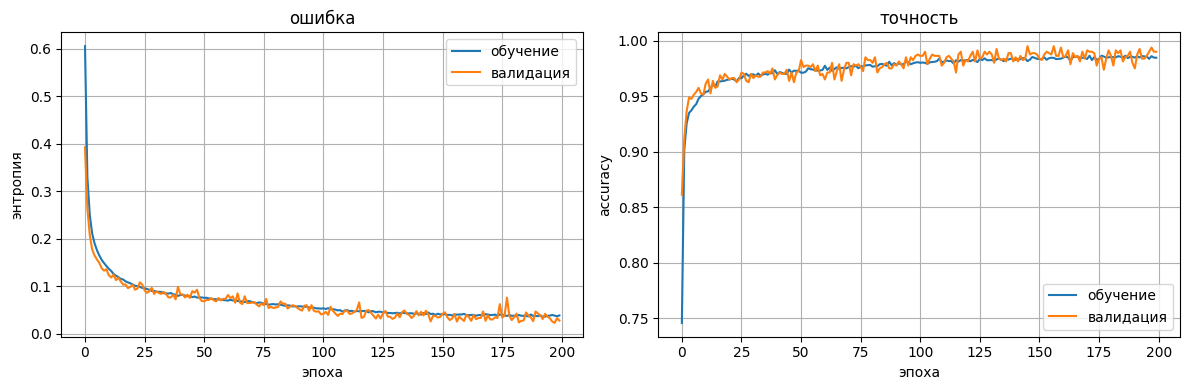

In [ ]:
plot_curve(model)

In [ ]:
x_new, labels_new = make_dots(3000)

In [ ]:
def plot_predictions(model,points,true_labels):
  probabilities = model.predict(points,verbose = 0) # получили вектор из 4 вероятности (57,82% 13,76% 8,98% 7,96%)
  predicted = np.argmax(probabilities,axis = 1) # потом берем наибольшую вероятность и считаем этот клас предсказанием модели

  fig, (ax1 , ax2) = plt.subplots(1,2,figsize=(12,4))
  sns.scatterplot(x = points[:,0],y = points[:,1], hue = true_labels, ax = ax1)
  sns.scatterplot(x = points[:,0],y = points[:,1], hue = predicted, ax = ax2)
  print(f"точность на новых точках: {np.mean(predicted == true_labels)}")


точность на новых точках: 0.0016666666666666668


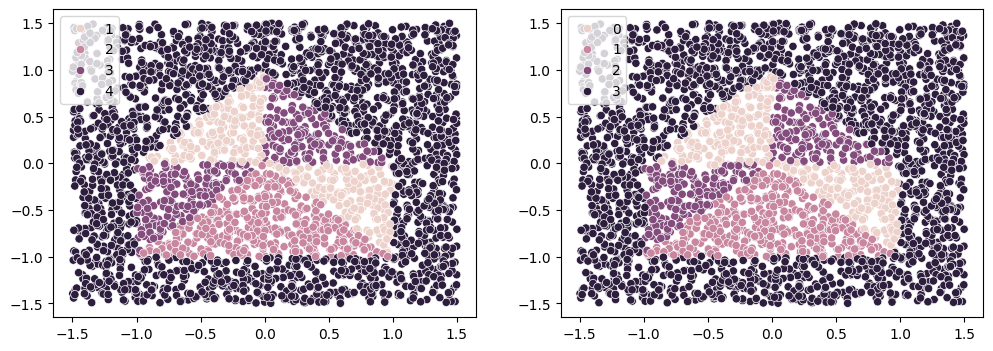

In [ ]:
plot_predictions(model, x_new, labels_new)

In [ ]:
big_model = build_model(rate=0.01, neurons=200)

In [ ]:
big_model.fit(X_train, y_train, epochs=100, batch_size=24, validation_split=0.2)

Epoch 1/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9817 - loss: 0.0693 - val_accuracy: 0.9794 - val_loss: 0.0720
Epoch 2/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9827 - loss: 0.0725 - val_accuracy: 0.9787 - val_loss: 0.0812
Epoch 3/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9828 - loss: 0.0674 - val_accuracy: 0.9819 - val_loss: 0.0626
Epoch 4/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9836 - loss: 0.0688 - val_accuracy: 0.9825 - val_loss: 0.0545
Epoch 5/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9828 - loss: 0.0685 - val_accuracy: 0.9919 - val_loss: 0.0296
Epoch 6/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9837 - loss: 0.0645 - val_accuracy: 0.9706 - val_loss: 0.1904
Epoch 7/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9828 - loss: 0.0644 - val_accuracy: 0.9856 - val_loss: 0.0461
Epoch 8/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9836 - loss: 0.0636 - val_accu

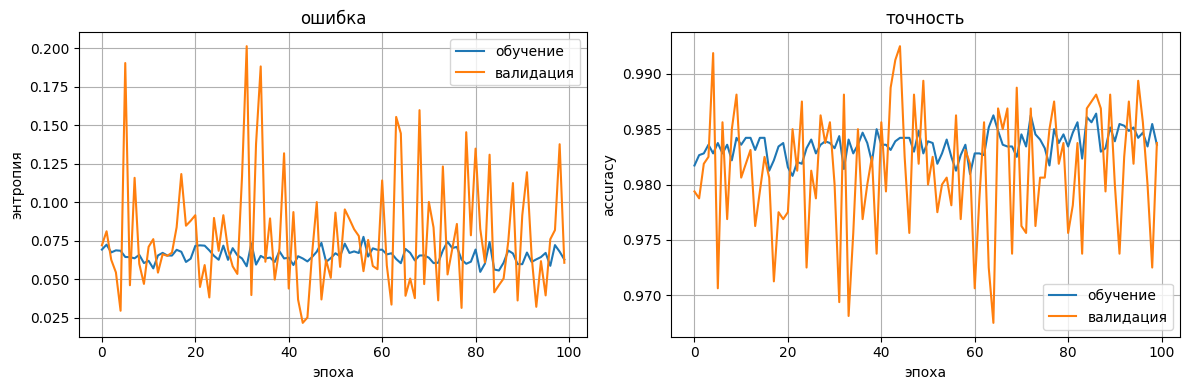

In [ ]:
plot_curve(big_model)

точность на новых точках: 0.0013333333333333333


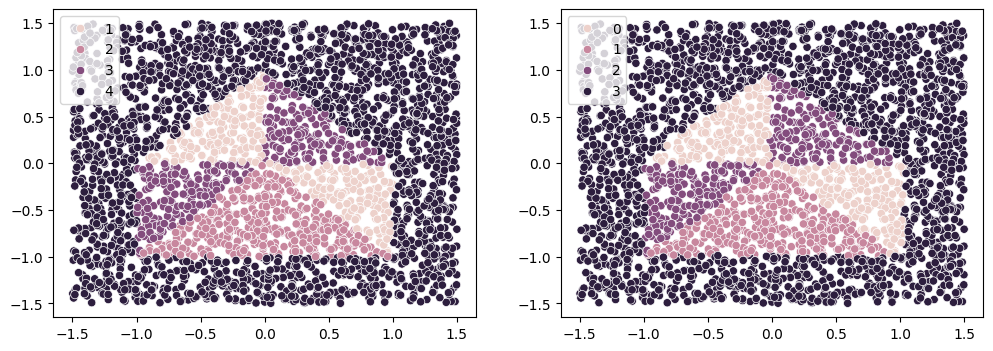

In [ ]:
plot_predictions(big_model, x_new, labels_new)

In [ ]:
big_loss, big_accuracy = big_model.evaluate(
    X_test, y_test, verbose=0
)

In [ ]:
def make_dots_noize(n = 10_000,noize_rate = 0.5):
  XY = np.random.uniform(-1.5,1.5, size = (n,2)).astype(np.float32)
  x = XY[:,0]
  y = XY[:,1]

  inside = between(x, -1, 1) & (y >= -1) & (y <= x + 1) & (y <= -x + 1)

  cond_4 =   ~inside

  cond_1 = (between(x, -1, 0) & between(y, 0, 1) & (y <= x + 1)) | \
          (between(x, 0, 1) & between(y, -1, 0) & (y >= -x))

  cond_2 = between(x, -1, 1) & between(y, -1, 0) & (y <= x) & (y <= -x)

  cond_3 = (between(x, -1, 0) & between(y, -1, 0) & (y >= x)) | \
            (between(x, 0, 1) & between(y, 0, 1) & (y <= -x + 1))


  labels = np.zeros(n, dtype=int)
  labels[cond_4] = 4
  labels[cond_1] = 1
  labels[cond_2] = 2
  labels[cond_3] = 3

  noize = np.random.normal(loc = 0,scale = noize_rate,size = XY.shape)
  noizy_XY = XY + noize

  return noizy_XY, labels

In [ ]:
XY, labels = make_dots_noize(5000, noize_rate=0.75)

df = pd.DataFrame({
    "X": XY[:,0],
    "Y": XY[:,1],
    "label": labels.astype(int)
})
Y = tf.keras.utils.to_categorical(labels - 1,num_classes = 4)
split = int(len(XY) * 0.8)
X_train,X_test =  XY[:split], XY[split:]
y_train, y_test =  Y[:split], Y[split:]

In [ ]:
small_model = build_model(rate = 0.001, neurons=90)

In [ ]:
small_model.fit(x = X_train, y = y_train, epochs=200, batch_size=24, validation_split=0.1)

Epoch 1/200
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6519 - loss: 0.9935 - val_accuracy: 0.6875 - val_loss: 0.8941
Epoch 2/200
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6775 - loss: 0.8997 - val_accuracy: 0.6875 - val_loss: 0.8886
Epoch 3/200
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6775 - loss: 0.8953 - val_accuracy: 0.6875 - val_loss: 0.8916
Epoch 4/200
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6775 - loss: 0.8937 - val_accuracy: 0.6875 - val_loss: 0.8873
Epoch 5/200
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6775 - loss: 0.8927 - val_accuracy: 0.6875 - val_loss: 0.8867
Epoch 6/200
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6775 - loss: 0.8919 - val_accuracy: 0.6875 - val_loss: 0.8889
Epoch 7/200
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6775 - loss: 0.8913 - val_accuracy: 0.6875 - val_loss: 0.8887
Epoch 8/200
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6775 - loss: 0.8911 - val_accu

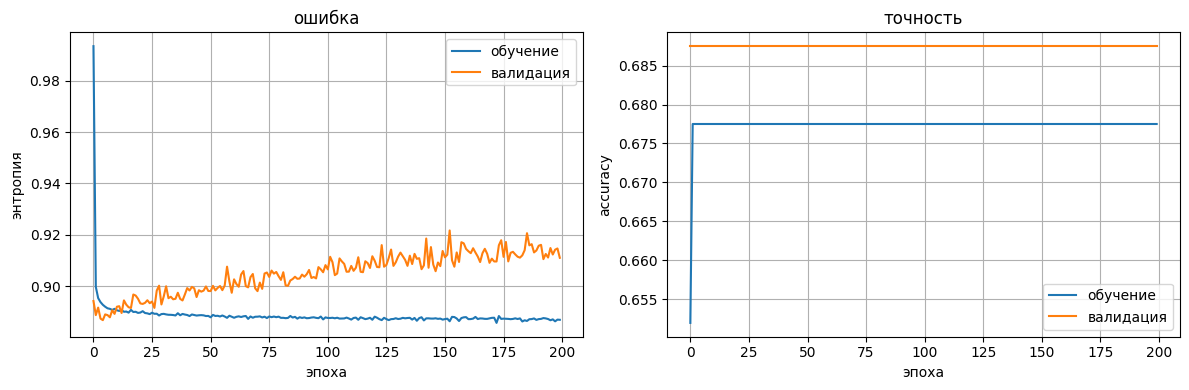

In [ ]:
plot_curve(small_model)

In [ ]:
x_new, labels_new = make_dots_noize(1000,noize_rate=0.75)

точность на новых точках: 0.116


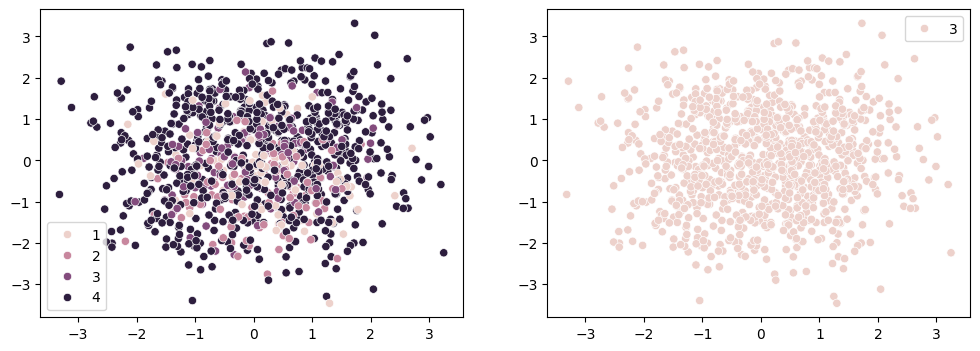

In [ ]:
plot_predictions(small_model,x_new,labels_new)